# **Zadanie 4**

- Proszę wybrać ulubiony język programowania.
- Proszę wygenerować macierz o rozmiarze $2^{3k} = 2^k \times 2^k \times 2^k$ dla  
  $k = 2,3,4$ o strukturze opisującej topologię trójwymiarowej  
  siatki zbudowanej z elementów sześciennych (wiersz = wierzchołek,  
  niezerowe losowe wartości w kolumnach – sąsiadujące wierzchołki siatki).
- Proszę użyć rekurencyjną procedurę kompresji macierzy z Zadania 3.
- Proszę narysować macierz skompresowaną używając rysowacza z zadania 3.
- Proszę przemnożyć macierz skompresowaną przez wektor (20 punktów).
- Proszę przemnożyć macierz skompresowaną przez samą siebie (20 punktów).

---

### **Raporty (dla par 2 osobowych)**

Proszę przygotować następujący raport:

- Proszę w raporcie opisać pseudo-kod swojego rekurencyjnego algorytmu.
- Proszę w raporcie umieścić wybrane najbardziej istotne fragmenty kodu.
- Proszę narysować wykres: oś pozioma – rozmiar macierzy  $2^{3k}$ dla $k = 2,3,4$,  oś pionowa – czas mnożenia macierzy skompresowanej przez wektor.
- Proszę dopasować wykres  $\alpha N^{\beta}$ do wykresów czasu mnożenia.  
  Jaka jest złożoność eksperymentalna?
- Proszę napisać dekonstrukcję macierzy gęstej z macierzy skompresowanej  
  i porównać wyniki mnożenia macierzy przez wektor licząc sumę różnicy kwadratów:
  $\|Ax - Hx\|_F^2 = \sum_{i} (A x_i - H x_i)^2$ $\quad$ (Norma Frobeniusa)

In [28]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread
from scipy.linalg import svdvals
import time
from scipy.optimize import curve_fit
from matplotlib.colors import Normalize

np.random.seed(0)

# Funkcje z lab3

In [29]:
from typing import Any, NewType, Optional

from numpy.typing import NDArray

ImageArray = NewType("ImageArray", NDArray[np.float32])
ChannelArray = NDArray[np.float32]

In [30]:
def load_image(file_path: str) -> ImageArray:
    image = imread(file_path).astype(np.float32) / 255
    assert image.ndim == 3 and image.shape[2] == 3, "Image must have shape (H, W, 3)"
    return ImageArray(image)

In [31]:
def extract_rgb(
    image: ImageArray,
) -> tuple[ChannelArray, ChannelArray, ChannelArray]:
    return image[..., 0], image[..., 1], image[..., 2]

In [32]:
def plot_channel(ax: Any, channel: ChannelArray, title: str) -> None:
    ax.imshow(channel, cmap="gray")
    ax.set_title(title)

In [33]:
def plot_image(image: ImageArray, title: str) -> None:
    _, axs = plt.subplots(2, 2, figsize=(10, 8), layout="tight")
    r, g, b = extract_rgb(image)
    plot_channel(axs[0, 0], image, title)
    plot_channel(axs[0, 1], r, "Red channel")
    plot_channel(axs[1, 0], g, "Green channel")
    plot_channel(axs[1, 1], b, "Blue channel")

In [34]:
def plot_image(image: ImageArray, title: str) -> None:
    _, axs = plt.subplots(2, 2, figsize=(10, 8), layout="tight")
    r, g, b = extract_rgb(image)
    plot_channel(axs[0, 0], image, title)
    plot_channel(axs[0, 1], r, "Red channel")
    plot_channel(axs[1, 0], g, "Green channel")
    plot_channel(axs[1, 1], b, "Blue channel")

In [35]:
def plot_matrix_image(bitmap: ImageArray, matrix_image: ImageArray, title: str) -> None:
    _, axs = plt.subplots(2, 2, figsize=(10, 8), layout="tight")
    plot_channel(axs[0, 0], bitmap, title)
    plot_channel(axs[0, 1], matrix_image[..., 0], "Red channel")
    plot_channel(axs[1, 0], matrix_image[..., 1], "Green channel")
    plot_channel(axs[1, 1], matrix_image[..., 2], "Blue channel")

In [36]:
def partial_svd(matrix: NDArray, k: int) -> tuple[NDArray, NDArray, NDArray]:
    """
    Parameters
        A : ndarray
            Matrix to decompose of a floating point numeric dtype.
        k : int
            Number of singular values and singular vectors to compute.
            Must satisfy 1 <= k <= kmax, where kmax=min(M, N).

    Returns
        u : ndarray, shape=(M, k)
            Unitary matrix having left singular vectors as columns.
        s : ndarray, shape=(k,)
            The singular values (in descending order).
        vt : ndarray, shape=(k, N)
            Unitary matrix having right singular vectors as rows.
    """
    u, s, vt = np.linalg.svd(matrix, full_matrices=False)
    return u[:, :k], s[:k], vt[:k, :]

In [37]:
@dataclass
class CompressedNode:
    # Hierarchical SVD representation
    u: Optional[NDArray[np.float32]] = None
    s: Optional[NDArray[np.float32]] = None
    vt: Optional[NDArray[np.float32]] = None

    # Children nodes
    # tl | tr
    # ---|---
    # bl | br
    tl: Optional["CompressedNode"] = None  # top-left
    tr: Optional["CompressedNode"] = None  # top-right
    bl: Optional["CompressedNode"] = None  # bottom-left
    br: Optional["CompressedNode"] = None  # bottom-right

    # Helpers
    @property
    def is_leaf(self) -> bool:
        return (
            (self.tl is None)
            and (self.tr is None)
            and (self.bl is None)
            and (self.br is None)
        )

    def compute_matrix(self, clip: bool = True) -> np.ndarray:
        if self.is_leaf:
            assert self.u is not None, "Macierz U musi być zdefiniowana w liściu."
            assert self.s is not None, "Wektor S musi być zdefiniowany w liściu."
            assert self.vt is not None, "Macierz V^T musi być zdefiniowana w liściu."

            result = self.u @ np.diag(self.s) @ self.vt
            return np.clip(result, 0.0, 1.0) if clip else result

        assert self.tl is not None, "Górny-lewy węzeł dziecka musi być zdefiniowany."
        assert self.tr is not None, "Górny-prawy węzeł dziecka musi być zdefiniowany."
        assert self.bl is not None, "Dolny-lewy węzeł dziecka musi być zdefiniowany."
        assert self.br is not None, "Dolny-prawy węzeł dziecka musi być zdefiniowany."

        tl = self.tl.compute_matrix(clip=clip)
        tr = self.tr.compute_matrix(clip=clip)
        bl = self.bl.compute_matrix(clip=clip)
        br = self.br.compute_matrix(clip=clip)

        return np.block([[tl, tr], [bl, br]])

    @property
    def matrix(self) -> np.ndarray:
        return self.compute_matrix(clip=True)

In [38]:
def create_tree(
    matrix: NDArray[np.float32], max_block_size: int, sv_threshold: float
) -> CompressedNode:
    m, n = matrix.shape
    u, s, vt = partial_svd(matrix, max_block_size)

    # s[-1] = smallest singular singular value
    if s[-1] < sv_threshold or min(m, n) <= 2 * max_block_size + 1:
        return CompressedNode(u, s, vt)

    node = CompressedNode()
    m2, n2 = m // 2, n // 2
    node.tl = create_tree(matrix[:m2, :n2], max_block_size, sv_threshold)
    node.tr = create_tree(matrix[:m2, n2:], max_block_size, sv_threshold)
    node.bl = create_tree(matrix[m2:, :n2], max_block_size, sv_threshold)
    node.br = create_tree(matrix[m2:, n2:], max_block_size, sv_threshold)
    return node

In [39]:
def get_sv_threshold(
    singular_values: NDArray[np.float32], target_svd_components: int
) -> float:
    assert (
        0 <= target_svd_components <= len(singular_values)
    ), f"`target_svd_components` range is (0, {len(singular_values)})"

    if target_svd_components == 1:
        return float("inf")

    elif target_svd_components == 0 or target_svd_components == len(singular_values):
        return float("-inf")

    else:
        return (
            singular_values[target_svd_components - 2]
            + singular_values[target_svd_components - 1]
        ) / 2

In [40]:
def fill_matrix_image(node, matrix_image, i, j, m, n):
    if node.is_leaf:
        x_0, y_0 = i, j
        x_1, y_1 = i + m, j + n

        # Black lines thickness
        x_size = node.s.shape[0]
        y_size = node.s.shape[0]

        matrix_image[x_0 : x_0 + x_size, y_0:y_1] = 0.0
        matrix_image[x_0:x_1, y_0 : y_0 + y_size] = 0.0
    else:
        m_mid = m // 2
        n_mid = n // 2
        if node.tl:
            fill_matrix_image(node.tl, matrix_image, i, j, m_mid, n_mid)
        if node.tr:
            fill_matrix_image(node.tr, matrix_image, i, j + n_mid, m_mid, n - n_mid)
        if node.bl:
            fill_matrix_image(node.bl, matrix_image, i + m_mid, j, m - m_mid, n_mid)
        if node.br:
            fill_matrix_image(
                node.br, matrix_image, i + m_mid, j + n_mid, m - m_mid, n - n_mid
            )

In [41]:
def create_matrix_image(root, shape):
    matrix_image = np.ones(shape, dtype=np.float32)

    fill_matrix_image(root, matrix_image, 0, 0, shape[0], shape[1])

    return matrix_image

In [42]:
def compress_image_demo(
    image: ImageArray, max_block_size: int, target_svd_components: int
):
    """
    Parameters
        image : ImageArray
            Image to compress.
        max_block_size : int
            Maximum block size to use for the SVD decomposition.
            (maximal rank)
        target_svd_components : int
            Number of singular values to keep in the SVD decomposition.
            (discarad other singular values)
    """
    r_channel, g_channel, b_channel = extract_rgb(image)

    r_singular_values = svdvals(r_channel)
    g_singular_values = svdvals(g_channel)
    b_singular_values = svdvals(b_channel)

    r_sv_threshold = get_sv_threshold(r_singular_values, target_svd_components)
    g_sv_threshold = get_sv_threshold(g_singular_values, target_svd_components)
    b_sv_threshold = get_sv_threshold(b_singular_values, target_svd_components)

    root_r = create_tree(r_channel, max_block_size, r_sv_threshold)
    root_g = create_tree(g_channel, max_block_size, g_sv_threshold)
    root_b = create_tree(b_channel, max_block_size, b_sv_threshold)

    bitmap_r = root_r.matrix
    bitmap_g = root_g.matrix
    bitmap_b = root_b.matrix

    bitmap = ImageArray(np.stack((bitmap_r, bitmap_g, bitmap_b), axis=-1))
    plot_image(
        bitmap,
        f"Compressed image ($r$={max_block_size}, $|\\delta|$={target_svd_components})",
    )

    matrix_image_r = create_matrix_image(root_r, bitmap_r.shape)
    matrix_image_g = create_matrix_image(root_g, bitmap_g.shape)
    matrix_image_b = create_matrix_image(root_b, bitmap_b.shape)

    matrix_image = ImageArray(
        np.stack((matrix_image_r, matrix_image_g, matrix_image_b), axis=-1)
    )
    plot_matrix_image(bitmap, matrix_image, "Matrix image")

In [43]:
def plot_compressed_image(
    image: ImageArray, max_block_size: int, target_svd_components: int
):
    r_channel, g_channel, b_channel = extract_rgb(image)

    r_singular_values = svdvals(r_channel)
    g_singular_values = svdvals(g_channel)
    b_singular_values = svdvals(b_channel)

    r_sv_threshold = get_sv_threshold(r_singular_values, target_svd_components)
    g_sv_threshold = get_sv_threshold(g_singular_values, target_svd_components)
    b_sv_threshold = get_sv_threshold(b_singular_values, target_svd_components)

    root_r = create_tree(r_channel, max_block_size, r_sv_threshold)
    root_g = create_tree(g_channel, max_block_size, g_sv_threshold)
    root_b = create_tree(b_channel, max_block_size, b_sv_threshold)

    bitmap_r = root_r.matrix
    bitmap_g = root_g.matrix
    bitmap_b = root_b.matrix

    bitmap = ImageArray(np.stack((bitmap_r, bitmap_g, bitmap_b), axis=-1))
    plot_image(bitmap,"Compressed image")

# Algorytmy

### Mnożenie macierzy przez wektor

```
FUNCTION matrix_vector_mult(v, X):
    IF v.sons = 0 THEN
        IF v.rank = 0 THEN
            RETURN zeros(size(A).rows)
        END IF
        RETURN v.U * (v.V * X)
    END IF

    rows ← size(X).rows
    X1 ← X(1 : rows/2, *)
    X2 ← X((rows/2 + 1) : rows, *)

    Y1^(1) ← matrix_vector_mult(v.sons(1), X1)
    Y1^(2) ← matrix_vector_mult(v.sons(2), X1)
    Y2^(1) ← matrix_vector_mult(v.sons(3), X2)
    Y2^(2) ← matrix_vector_mult(v.sons(4), X2)

    RETURN [
        Y1^(1) + Y2^(1);
        Y1^(2) + Y2^(2)
    ]
```

In [44]:
def compressed_matrix_vector_mult(node: CompressedNode, vector: NDArray[np.float32]) -> NDArray[np.float32]:
    if node.is_leaf:        
        return node.u @ (np.diag(node.s) @ (node.vt @ vector))

    size = vector.shape[0]
    half_size = size // 2

    v1 = vector[:half_size]
    v2 = vector[half_size:]

    y_tl = compressed_matrix_vector_mult(node.tl, v1)
    y_tr = compressed_matrix_vector_mult(node.tr, v2)
    y_bl = compressed_matrix_vector_mult(node.bl, v1)
    y_br = compressed_matrix_vector_mult(node.br, v2)

    upper = y_tl + y_tr
    lower = y_bl + y_br

    return np.concatenate([upper, lower])

### Dodawanie macierzy

```
FUNCTION matrix_matrix_add(v, w):
    IF v.sons = 0 AND w.sons = 0 AND v.rank = 0 AND w.rank = 0 THEN
        RETURN zeros(size(A))  // Zero matrix of proper dimension
    END IF

    IF v.sons = 0 AND w.sons = 0 AND v.rank != 0 AND w.rank != 0 THEN
        RETURN SVDOfCompressed([v.U1w.U1, v.V1w.V1])
    END IF

    IF v.sons != 0 AND w.sons != 0 THEN
        // Divide matrices into blocks and perform recursive addition
        RETURN [
            matrix_matrix_add(A1, B1), matrix_matrix_add(A2, B2);
            matrix_matrix_add(A3, B3), matrix_matrix_add(A4, B4)
        ]
    END IF

    IF v.sons = 0 AND w.sons != 0 THEN
        A = U1 V1
        Split U1 into 2 parts: ( U1 = [U1', U1''] )
        Split V1 into 2 parts: ( V1 = [V1', V1''] )

        RETURN [
            matrix_matrix_add(U1' * V1', B1), matrix_matrix_add(U1' * V1', B2);
            matrix_matrix_add(U1'' * V1', B3), matrix_matrix_add(U1'' * V1', B4)
        ]
    END IF

    IF v.sons != 0 AND w.sons = 0 THEN
        // Symmetric case of the previous one
        PERFORM THE SAME AS BEFORE
    END IF

    IF v AND w ARE NUMBERS THEN
        RETURN [v + w]
    END IF
```

In [45]:
def split_leaf_to_blocks(node: CompressedNode) -> CompressedNode:
    assert node.is_leaf, "Matrix has to ba a leaf."

    m, n = node.u.shape[0], node.vt.shape[1]
    m2, n2 = m // 2, n // 2

    matrix = node.u @ np.diag(node.s) @ node.vt

    tl = matrix[:m2, :n2]
    tr = matrix[:m2, n2:]
    bl = matrix[m2:, :n2]
    br = matrix[m2:, n2:]

    return CompressedNode(
        tl=create_leaf_from_block(tl),
        tr=create_leaf_from_block(tr),
        bl=create_leaf_from_block(bl),
        br=create_leaf_from_block(br)
    )

def create_leaf_from_block(block: np.ndarray) -> CompressedNode:
    u, s, vt = np.linalg.svd(block, full_matrices=False)
    return CompressedNode(u=u, s=s, vt=vt)

def svd_of_compressed(node1: CompressedNode, node2: CompressedNode):
    matrix1 = node1.u @ np.diag(node1.s) @ node1.vt
    matrix2 = node2.u @ np.diag(node2.s) @ node2.vt
    summed_matrix = matrix1 + matrix2
    u, s, vt = np.linalg.svd(summed_matrix, full_matrices=False)
    return u, s, vt

In [46]:
def compressed_matrix_add(node1: CompressedNode, node2: CompressedNode) -> CompressedNode:
    if node1.is_leaf and node2.is_leaf:
        if node1.s is None and node2.s is None:
            return CompressedNode()
        elif node1.s is None:
            return node2
        elif node2.s is None:
            return node1
        else:
            new_u, new_s, new_vt = svd_of_compressed(node1, node2)
            return CompressedNode(u=new_u, s=new_s, vt=new_vt)

    if node1.is_leaf and not node2.is_leaf:
        node1_split = split_leaf_to_blocks(node1)
        return compressed_matrix_add(node1_split, node2)

    if not node1.is_leaf and node2.is_leaf:
        node2_split = split_leaf_to_blocks(node2)
        return compressed_matrix_add(node1, node2_split)

    return CompressedNode(
        tl=compressed_matrix_add(node1.tl, node2.tl),
        tr=compressed_matrix_add(node1.tr, node2.tr),
        bl=compressed_matrix_add(node1.bl, node2.bl),
        br=compressed_matrix_add(node1.br, node2.br)
    )

### Mnożenie macierzy

```
FUNCTION matrix_matrix_mult(v, w):
    IF v.sons = 0 AND w.sons = 0 THEN
        IF v.rank = 0 AND w.rank = 0 THEN
            RETURN zero_matrix(size(A))
        END IF
        
        IF v.rank != 0 AND w.rank != 0 THEN
            RETURN v.U * (v.V * w.U) * w.V
        END IF
    END IF

    IF v.sons != 0 AND w.sons != 0 THEN
        // Divide matrices into blocks and perform recursive multiplication
        RETURN [
            matrix_matrix_mult(A1, B1) + matrix_matrix_mult(A2, B3), 
            matrix_matrix_mult(A1, B2) + matrix_matrix_mult(A2, B4);
            matrix_matrix_mult(A3, B1) + matrix_matrix_mult(A4, B3), 
            matrix_matrix_mult(A3, B2) + matrix_matrix_mult(A4, B4)
        ]
    END IF

    IF v.sons = 0 AND w.sons != 0 THEN
        A = U1 * V1
        Split U1 into 2 parts: \( U1 = [U1', U1''] \)
        Split V1 into 2 parts: \( V1 = [V1', V1''] \)

        RETURN [
            matrix_matrix_mult(U1' * V1', B1) + matrix_matrix_mult(U1' * V1', B3), 
            matrix_matrix_mult(U1' * V1', B2) + matrix_matrix_mult(U1' * V1', B4);
            matrix_matrix_mult(U1'' * V1', B1) + matrix_matrix_mult(U1'' * V1', B3), 
            matrix_matrix_mult(U1'' * V1', B2) + matrix_matrix_mult(U1'' * V1', B4)
        ]
    END IF

    IF v.sons != 0 AND w.sons = 0 THEN
        // Symmetric case of the previous one
        EXECUTE THE SAME AS PREVIOUS CASE
    END IF

    IF v AND w ARE NUMBERS THEN
        RETURN v * w
    END IF
```

In [47]:
def compressed_matrix_mult(node1: CompressedNode, node2: CompressedNode) -> CompressedNode:
    if node1.is_leaf and node2.is_leaf:
        intermediate_matrix = node1.vt @ node2.u
        inter_u, inter_s, inter_vt = np.linalg.svd(intermediate_matrix, full_matrices=False)

        new_u = node1.u @ np.diag(node1.s) @ inter_u
        new_s = inter_s
        new_vt = inter_vt @ np.diag(node2.s) @ node2.vt
    
        return CompressedNode(new_u, new_s, new_vt)

    if node1.is_leaf and not node2.is_leaf:
        node1 = split_leaf_to_blocks(node1)

    if not node1.is_leaf and node2.is_leaf:
        node2 = split_leaf_to_blocks(node2)

    return CompressedNode(
        tl=compressed_matrix_add(compressed_matrix_mult(node1.tl, node2.tl), 
                                 compressed_matrix_mult(node1.tr, node2.bl)),
        tr=compressed_matrix_add(compressed_matrix_mult(node1.tl, node2.tr), 
                                 compressed_matrix_mult(node1.tr, node2.br)),
        bl=compressed_matrix_add(compressed_matrix_mult(node1.bl, node2.tl), 
                                 compressed_matrix_mult(node1.br, node2.bl)),
        br=compressed_matrix_add(compressed_matrix_mult(node1.bl, node2.tr), 
                                 compressed_matrix_mult(node1.br, node2.br))
    )

## Macierz odwzorowująca topologię siatki 3D

In [48]:
def index_to_coordinates(index, size):
    z = index // (size ** 2)
    y = (index % (size ** 2)) // size
    x = index % size
    return x, y, z

def coordinates_to_index(x, y, z, size):
    return z * (size ** 2) + y * size + x

def generate_3d_mesh_matrix(k):
    grid_size = 2 ** k
    num_vertices = grid_size ** 3
    adjacency_matrix = np.zeros((num_vertices, num_vertices))

    for index in range(num_vertices):
        x, y, z = index_to_coordinates(index, grid_size)
        neighbors = [
            (x - 1, y, z), (x + 1, y, z),
            (x, y - 1, z), (x, y + 1, z),
            (x, y, z - 1), (x, y, z + 1),
        ]

        for nx, ny, nz in neighbors:
            if 0 <= nx < grid_size and 0 <= ny < grid_size and 0 <= nz < grid_size:
                neighbor_index = coordinates_to_index(nx, ny, nz, grid_size)
                adjacency_matrix[index, neighbor_index] = np.random.random()

    return adjacency_matrix

In [49]:
def generate_compressed_mesh_matrix_tree(k):
    matrix = generate_3d_mesh_matrix(k)
    compressed_matrix_tree = create_tree(matrix, max_block_size=2, sv_threshold=0.1)
    return compressed_matrix_tree

# Obrazki do testów

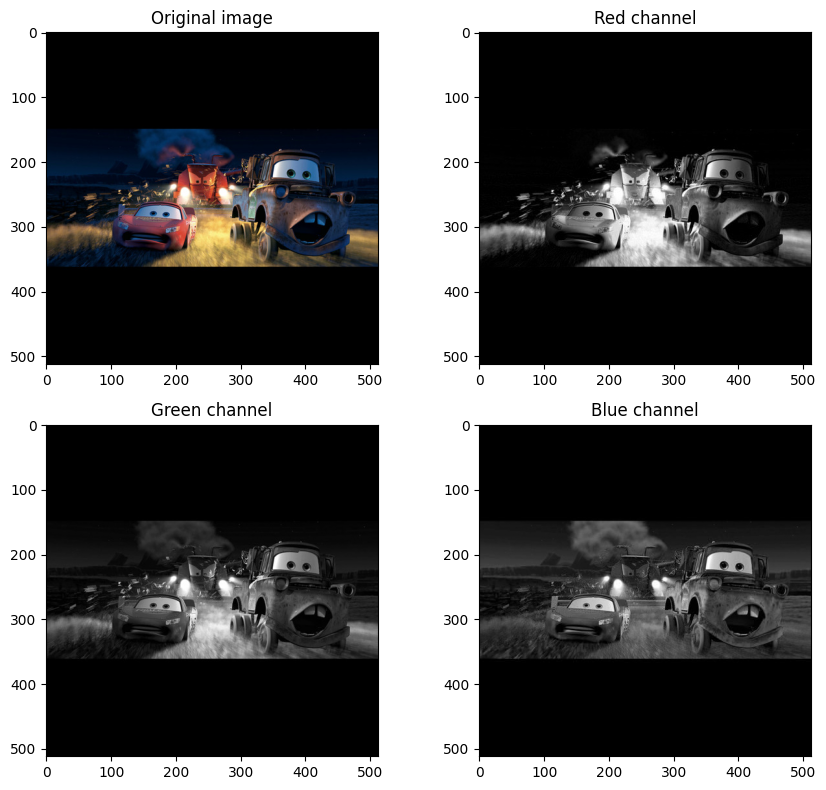

In [50]:
image = load_image(r"data/mcQueen.jpg")
plot_image(image, "Original image")

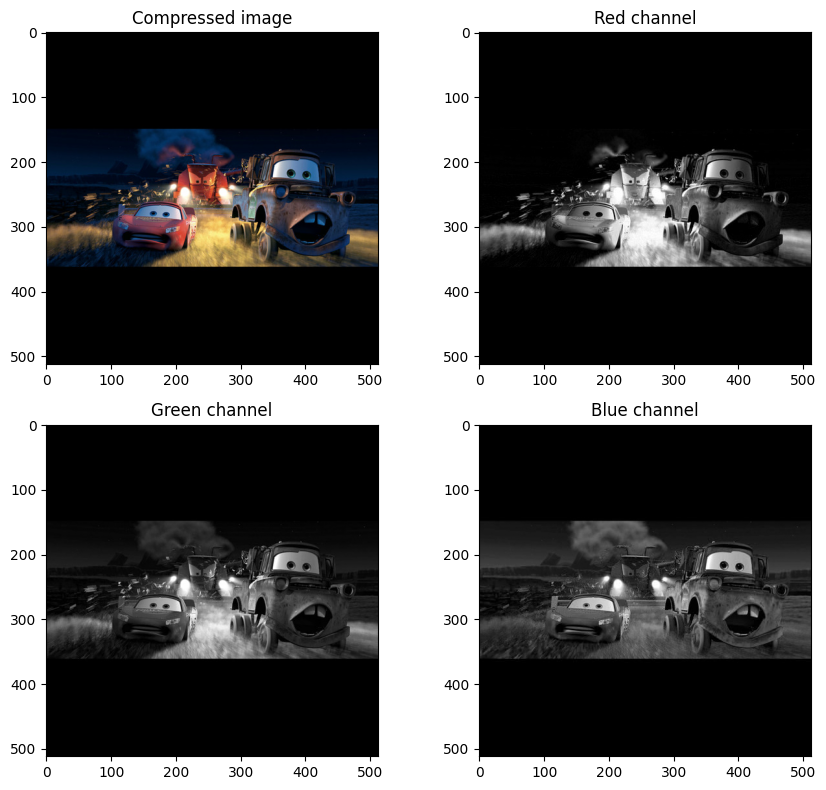

In [51]:
plot_compressed_image(image, max_block_size = 4, target_svd_components = 256)

# Funkcje używane do testów

In [52]:
def calculate_svd_threshold(matrix, target_svd_components=256):
    singular_values = svdvals(matrix)
    return get_sv_threshold(singular_values, target_svd_components)

def create_compressed_addition(matrix1, matrix2, max_block_size, sv_threshold, convert_to_img=False):
    compressed_matrix_tree1 = create_tree(matrix1, max_block_size=max_block_size, sv_threshold=sv_threshold)
    compressed_matrix_tree2 = create_tree(matrix2, max_block_size=max_block_size, sv_threshold=sv_threshold)
    
    compressed_result = compressed_matrix_add(compressed_matrix_tree1, compressed_matrix_tree2)
    compressed_addition = compressed_result.compute_matrix(clip=False)
    if convert_to_img:
        compressed_addition = np.clip(compressed_addition / 2, 0, 1)
    return compressed_addition

def create_regular_addition(matrix1, matrix2, max_block_size, sv_threshold, convert_to_img=False):
    compressed_matrix_tree1 = create_tree(matrix1, max_block_size=max_block_size, sv_threshold=sv_threshold)
    compressed_matrix_tree2 = create_tree(matrix2, max_block_size=max_block_size, sv_threshold=sv_threshold)
    
    regular_addition = compressed_matrix_tree1.compute_matrix(clip=False) + compressed_matrix_tree2.compute_matrix(clip=False)
    if convert_to_img:
        regular_addition = np.clip(regular_addition / 2, 0, 1)
    return regular_addition

def regularized_inverse(A, lambda_reg=0.1, threshold_reg=0.1):
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    S_stabilized = np.where(S > threshold_reg, S / (S**2 + lambda_reg), 0)
    A_pinv = Vt.T @ np.diag(S_stabilized) @ U.T
    return A_pinv

def create_compressed_multiplication(matrix1, matrix2, max_block_size, sv_threshold, convert_to_img=False, lambda_reg=0.1, threshold_reg=0.1):
    compressed_matrix_tree1 = create_tree(matrix1, max_block_size=max_block_size, sv_threshold=sv_threshold)
    compressed_matrix_tree2 = create_tree(matrix2, max_block_size=max_block_size, sv_threshold=sv_threshold)
    matrix_pinv = regularized_inverse(compressed_matrix_tree1.compute_matrix(clip=False), lambda_reg, threshold_reg)
    
    compressed_result = compressed_matrix_mult(compressed_matrix_tree1, compressed_matrix_tree2)
    compressed_multiplication = compressed_result.compute_matrix(clip=False)
    if convert_to_img:
        compressed_multiplication = np.clip(compressed_multiplication @ matrix_pinv, 0, 1)
    return compressed_multiplication

def create_regular_multiplication(matrix1, matrix2, max_block_size, sv_threshold, convert_to_img=False, lambda_reg=0.1, threshold_reg=0.1):
    compressed_matrix_tree1 = create_tree(matrix1, max_block_size=max_block_size, sv_threshold=sv_threshold)
    compressed_matrix_tree2 = create_tree(matrix2, max_block_size=max_block_size, sv_threshold=sv_threshold)
    matrix_pinv = regularized_inverse(compressed_matrix_tree1.compute_matrix(clip=False), lambda_reg, threshold_reg)
    
    regular_multiplication = compressed_matrix_tree1.compute_matrix(clip=False) @ compressed_matrix_tree2.compute_matrix(clip=False)
    if convert_to_img:
        regular_multiplication = np.clip(regular_multiplication @ matrix_pinv, 0, 1)
    return regular_multiplication

def compare_matrices(matrix1, matrix2):
    close_mask = np.isclose(matrix1, matrix2, atol=1e-4)
    num_close = np.sum(close_mask)
    total_elements = matrix1.size
    percentage_close = (num_close / total_elements) * 100
    return num_close, total_elements, percentage_close

def compare_vectors(vector1, vector2):
    close_mask = np.isclose(vector1, vector2, atol=1e-4)
    num_close = np.sum(close_mask)
    total_elements = vector1.size
    percentage_close = (num_close / total_elements) * 100
    return num_close, total_elements, percentage_close

def plot_matrices(regular_addition, compressed_addition, title=None, operation=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(title, fontsize=20, y=1.0)
    
    axes[0].imshow(regular_addition, cmap="grey")
    axes[0].set_title(f"Regular {operation}")
    axes[0].axis("off")
    
    axes[1].imshow(compressed_addition, cmap="grey")
    axes[1].set_title(f"Compressed {operation}")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

def compare_image_channels(matrix1, matrix2, max_block_size, target_svd_components, title=None, operation=None, lambda_reg=0.1, threshold_reg=0.1):
    sv_threshold1 = calculate_svd_threshold(matrix1, target_svd_components)
    sv_threshold2 = calculate_svd_threshold(matrix2, target_svd_components)
    if operation == "Addition":
        compressed_operation = create_compressed_addition(matrix1, matrix2, max_block_size, sv_threshold1, convert_to_img=True)
        regular_operation = create_regular_addition(matrix1, matrix2, max_block_size, sv_threshold2, convert_to_img=True)
    elif operation == "Multiplication":
        compressed_operation = create_compressed_multiplication(matrix1, matrix2, max_block_size, sv_threshold1, convert_to_img=True, 
                                                                lambda_reg=lambda_reg, threshold_reg=threshold_reg)
        regular_operation = create_regular_multiplication(matrix1, matrix2, max_block_size, sv_threshold2, convert_to_img=True, 
                                                          lambda_reg=lambda_reg, threshold_reg=threshold_reg)
    elif operation == None:
        raise ValueError("No operation given")
    else:
        raise ValueError(f"Unknown operation: {operation}")

    num_close, total_elements, percentage_close = compare_matrices(compressed_operation, regular_operation)

    plot_matrices(regular_operation, compressed_operation, title, operation=operation)

    print(f"Number of matching values: {num_close}/{total_elements}")
    print(f"Percentage of matching values: {percentage_close:.2f}%")

def compare_rgb_channels(image, max_block_size, target_svd_components, operation=None, lambda_reg=0.1, threshold_reg=0.1):
    r, g, b = extract_rgb(image)
    
    regular_operation_rgb = []
    compressed_operation_rgb = []

    for channel in [r, g, b]:
        sv_threshold = calculate_svd_threshold(channel, target_svd_components)
        if operation == "Addition":
            compressed_operation = create_compressed_addition(channel, channel, max_block_size, sv_threshold, convert_to_img=True)
            regular_operation = create_regular_addition(channel, channel, max_block_size, sv_threshold, convert_to_img=True)
        elif operation == "Multiplication":
            compressed_operation = create_compressed_multiplication(channel, channel, max_block_size, sv_threshold, convert_to_img=True, 
                                                                    lambda_reg=lambda_reg, threshold_reg=threshold_reg)
            regular_operation = create_regular_multiplication(channel, channel, max_block_size, sv_threshold, convert_to_img=True, 
                                                              lambda_reg=lambda_reg, threshold_reg=threshold_reg)
        elif operation == None:
            raise ValueError("No operation given")
        else:
            raise ValueError(f"Unknown operation: {operation}")

        regular_operation_rgb.append(regular_operation)
        compressed_operation_rgb.append(compressed_operation)

    regular_operation_rgb = np.stack(regular_operation_rgb, axis=-1)
    compressed_operation_rgb = np.stack(compressed_operation_rgb, axis=-1)

    num_close, total_elements, percentage_close = compare_matrices(compressed_operation_rgb, regular_operation_rgb)

    plot_matrices(regular_operation_rgb, compressed_operation_rgb, title="Full RGB image", operation="Addition")

    print(f"Number of matching values: {num_close}/{total_elements}")
    print(f"Percentage of matching values: {percentage_close:.2f}%")

def compare_image_additions(image, max_block_size, target_svd_components):
    r, g, b = extract_rgb(image)
    compare_image_channels(r, r, max_block_size, target_svd_components, title="Red Channel", operation="Addition")
    compare_image_channels(g, g, max_block_size, target_svd_components, title="Green Channel", operation="Addition")
    compare_image_channels(b, b, max_block_size, target_svd_components, title="Blue Channel", operation="Addition")
    compare_rgb_channels(image, max_block_size, target_svd_components, operation="Addition")

def compare_image_multiplications(image, max_block_size, target_svd_components, lambda_reg=0.1, threshold_reg=0.1):
    r, g, b = extract_rgb(image)
    compare_image_channels(r, r, max_block_size, target_svd_components, title="Red Channel", operation="Multiplication", 
                           lambda_reg=lambda_reg, threshold_reg=threshold_reg)
    compare_image_channels(g, g, max_block_size, target_svd_components, title="Green Channel", operation="Multiplication", 
                           lambda_reg=lambda_reg, threshold_reg=threshold_reg)
    compare_image_channels(b, b, max_block_size, target_svd_components, title="Blue Channel", operation="Multiplication", 
                           lambda_reg=lambda_reg, threshold_reg=threshold_reg)
    compare_rgb_channels(image, max_block_size, target_svd_components, operation="Multiplication", lambda_reg=lambda_reg, threshold_reg=threshold_reg)

# Testy

## Mnożenie macierzy przez wektor

#### Test 1

Niech $M_{com}$ będzie macierzą skompresowaną powstałą z oryginalnej macierzy $M_{org}$

Niech $M_{dec}$ będzie macierzą powstałą przez dekmprempresje macierzy skompresowanej $M_{com}$

Niech $X$ będzie losowym wektorem

Poniższy test sprwadza, czy algorytm mnożenia macierzy $M_{com}$ przez wektor $X$ (wraz z poźniejszą dekompresją) zwraca takie same wyniki z dokładnością do $10^{-4}$ jak proste przemnożenie macierzy $M_{dec}$ przez wektor $X$ na przykładzie macierzy odwzorowujących topologię siatki 3D.

In [484]:
k_values = [2,3,4]
for k in k_values:
    print(f'k = {k}')
    matrix = generate_3d_mesh_matrix(k)
    vector = np.random.rand(matrix.shape[1])
    
    target_svd_components = 16
    singular_values = svdvals(matrix)
    sv_threshold = get_sv_threshold(singular_values, target_svd_components)
    compressed_matrix_tree = create_tree(matrix, max_block_size=2, sv_threshold=sv_threshold)
    
    compressed_result = compressed_matrix_vector_mult(compressed_matrix_tree, vector)
    regular_result = compressed_matrix_tree.compute_matrix(clip=False) @ vector
    num_close, total_elements, percentage_close = compare_vectors(compressed_result, regular_result)
    print(f"Number of matching values: {num_close}/{total_elements}")
    print(f"Percentage of matching values: {percentage_close:.2f}%")
    print("")

k = 2
Number of matching values: 64/64
Percentage of matching values: 100.00%

k = 3
Number of matching values: 512/512
Percentage of matching values: 100.00%

k = 4
Number of matching values: 4096/4096
Percentage of matching values: 100.00%



## Dodawanie macierzy

#### Test 2

Niech $M_{com}$ będzie macierzą skompresowaną powstałą z oryginalnej macierzy $M_{org}$

Niech $M_{dec}$ będzie macierzą powstałą przez dekmprempresje macierzy skompresowanej $M_{com}$ 

Poniższy test sprwadza, czy algorytm dodawania macierzy $M_{com}$ do samej siebie (wraz z poźniejszą dekompresją) zwraca takie same wyniki z dokładnością do $10^{-4}$ jak proste dodanie macierzy $M_{dec}$ do samej siebie na przykładzie macierzy odwzorowujących topologię siatki 3D.

In [155]:
k_values=[2, 3, 4]
target_svd_components = 16
max_block_size = 2

for k in k_values:
    print(f'k = {k}')
    matrix = generate_3d_mesh_matrix(k)
    sv_threshold = calculate_svd_threshold(matrix, target_svd_components)
    
    compressed_addition = create_compressed_addition(matrix, matrix, sv_threshold, max_block_size, convert_to_img=False)
    regular_addition = create_regular_addition(matrix, matrix, sv_threshold, max_block_size, convert_to_img=False)

    num_close, total_elements, percentage_close = compare_matrices(compressed_addition, regular_addition)
    
    print(f"Number of matching values: {num_close}/{total_elements}")
    print(f"Percentage of matching values: {percentage_close:.2f}%")
    print("")

k = 2
Number of matching values: 4096/4096
Percentage of matching values: 100.00%

k = 3
Number of matching values: 262144/262144
Percentage of matching values: 100.00%

k = 4
Number of matching values: 16777216/16777216
Percentage of matching values: 100.00%



#### Test 3

Niech $M_{com}$ będzie macierzą skompresowaną powstałą z oryginalnej macierzy $M_{org}$

Niech $M_{dec}$ będzie macierzą powstałą przez dekmprempresje macierzy skompresowanej $M_{com}$ 

Poniższy test sprwadza, czy algorytm dodawania macierzy $M_{com}$ do samej siebie (wraz z poźniejszą dekompresją) zwraca takie same wyniki z dokładnością do $10^{-4}$ jak proste dodanie macierzy $M_{dec}$ do samej siebie na przykładzie rzeczywistego obrazu ($M_{org}$). W celu umożliwienia wyświetlenia wyników w przystępnej formie wyniki tych dodawań są dzielone przez 2. Porównanie wyników następuje dopiero po wykoniu wszystkich tych operacji.

Następują więc operacje:

1) $ \text{dec}(\text{add}(M_{com}, M_{com})/2) = M_{dec} $

2) $ (M_{dec} + M_{dec})/2 = M_{dec} $

$\text{dec}$ - dekompresja

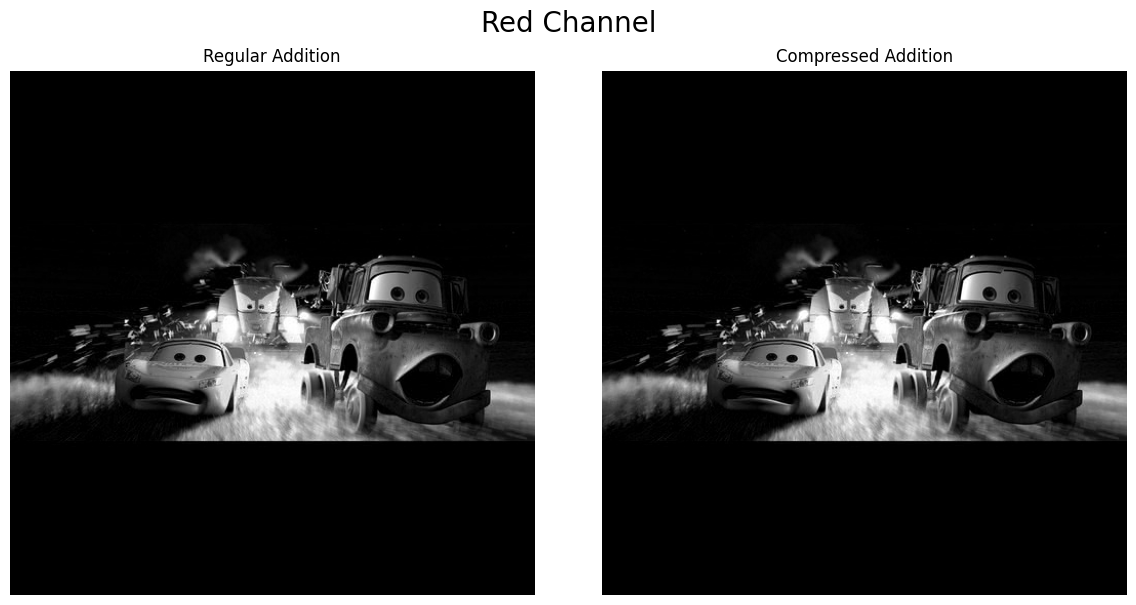

Number of matching values: 262144/262144
Percentage of matching values: 100.00%


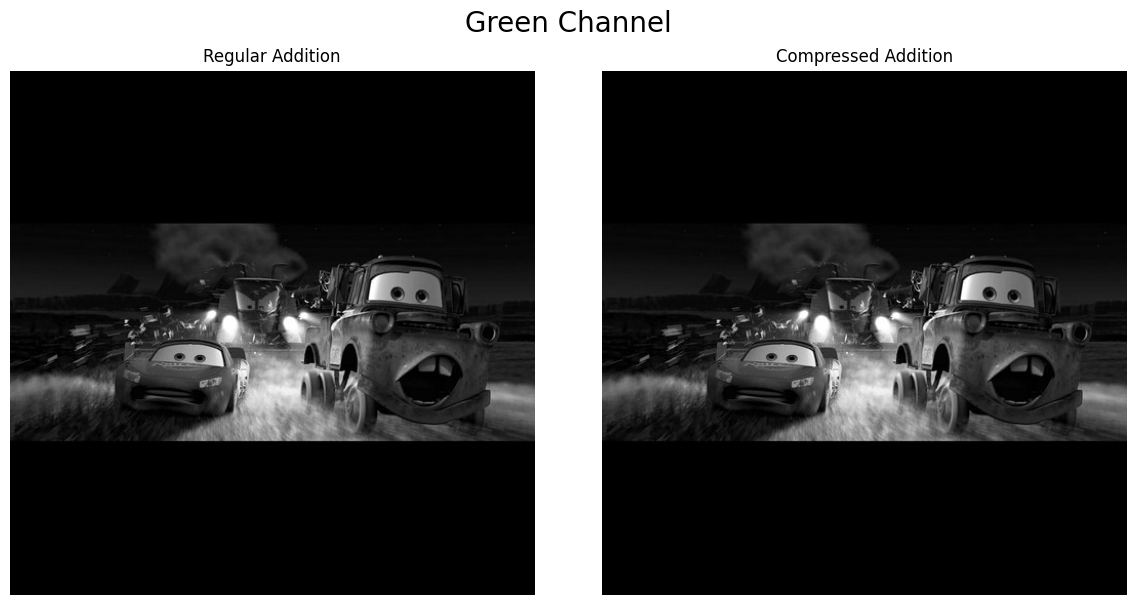

Number of matching values: 262144/262144
Percentage of matching values: 100.00%


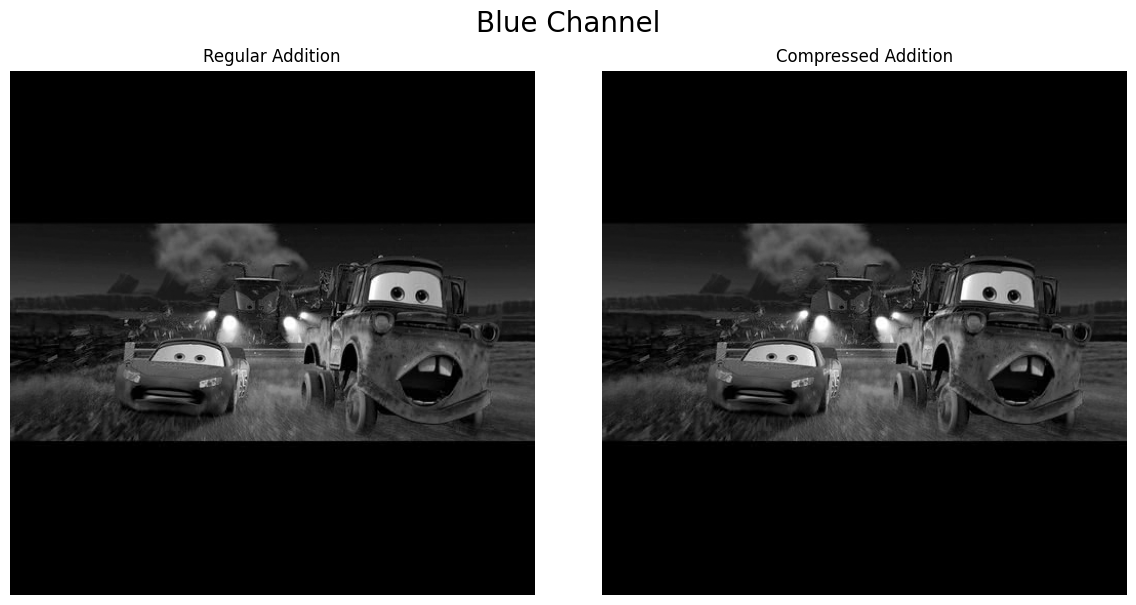

Number of matching values: 262144/262144
Percentage of matching values: 100.00%


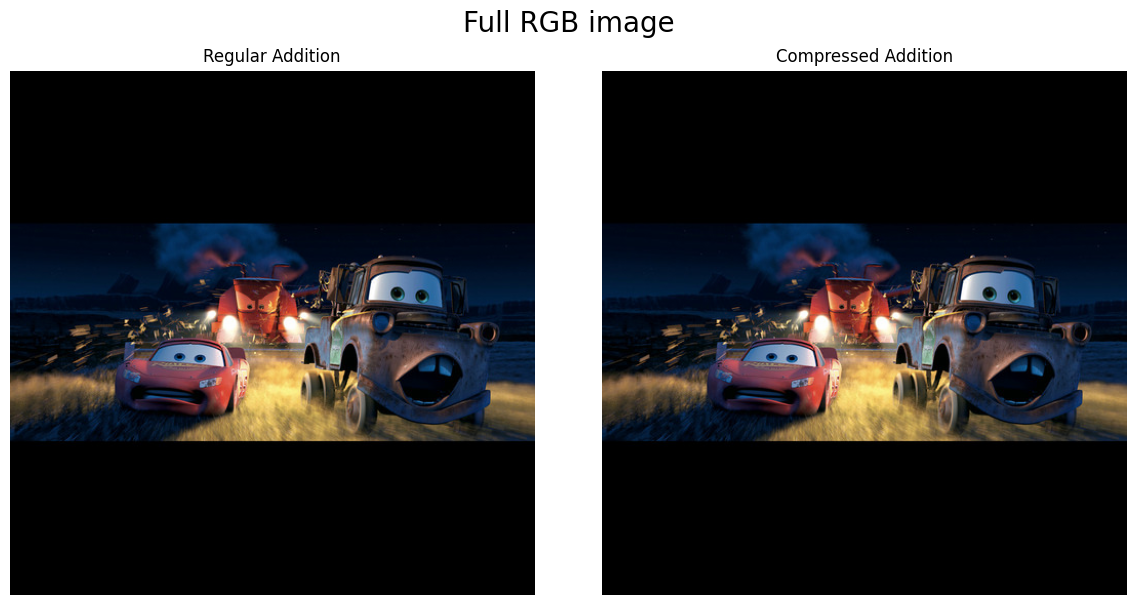

Number of matching values: 786432/786432
Percentage of matching values: 100.00%


In [507]:
compare_image_additions(image, max_block_size = 4, target_svd_components = 256)

## Mnożenie macierzy

#### Test 4

Niech $M_{com}$ będzie macierzą skompresowaną powstałą z oryginalnej macierzy $M_{org}$

Niech $M_{dec}$ będzie macierzą powstałą przez dekmprempresje macierzy skompresowanej $M_{com}$ 

Poniższy test sprwadza, czy algorytm mnożenia macierzy $M_{com}$ przez samą siebie (wraz z poźniejszą dekompresją) zwraca takie same wyniki z dokładnością do $10^{-4}$ jak proste przemnożenie macierzy $M_{dec}$ przez samą siebie na przykładzie macierzy odwzorowujących topologię siatki 3D.

In [174]:
k_values=[2, 3]
target_svd_components = 16
max_block_size = 2

for k in k_values:
    print(f'k = {k}')
    matrix = generate_3d_mesh_matrix(k)
    sv_threshold = calculate_svd_threshold(matrix, target_svd_components)
    
    compressed_multiplication = create_compressed_multiplication(matrix, matrix, sv_threshold, max_block_size, convert_to_img=False)
    regular_multiplication = create_regular_multiplication(matrix, matrix, sv_threshold, max_block_size, convert_to_img=False)

    num_close, total_elements, percentage_close = compare_matrices(compressed_multiplication, regular_multiplication)
    
    print(f"Number of matching values: {num_close}/{total_elements}")
    print(f"Percentage of matching values: {percentage_close:.2f}%")
    print("")

k = 2
Number of matching values: 4096/4096
Percentage of matching values: 100.00%

k = 3
Number of matching values: 262144/262144
Percentage of matching values: 100.00%



#### Test 5

Niech $M_{com}$ będzie macierzą skompresowaną powstałą z oryginalnej macierzy $M_{org}$

Niech $M_{dec}$ będzie macierzą powstałą przez dekmprempresje macierzy skompresowanej $M_{com}$ 

Poniższy test sprwadza, czy algorytm mnożenia macierzy $M_{com}$ przez samą siebie (wraz z poźniejszą dekompresją) zwraca takie same wyniki z dokładnością do $10^{-4}$ jak proste przemnożenie macierzy $M_{dec}$ przez samą siebie na przykładzie rzeczywistego obrazu ($M_{org}$). W celu umożliwienia wyświetlenia wyników w przystępnej formie wyniki tych mnożeń są następnie mnożone przez macierz $M_{pinv}$, gdzie $M_{pinv}$ jest macierzą zbliżoną do $M_{dec}^{-1}$ (przemnożenie przez macierz odwrotną nie jest możliwe, ponieważ $M_{dec}$ jest macierzą osobliwą). Porównanie wyników następuje dopiero po wykoniu wszystkich tych operacji.

Następują więc operacje:

1) $ \text{dec}(\text{mult}(M_{com}, M_{com})) \cdot M_{pinv} \approx M_{dec} $

2) $ M_{dec} \cdot M_{dec} \cdot M_{pinv} \approx M_{dec} $

$\text{dec}$ - dekompresja

$M_{pinv}$ jest wyznaczany przy pomocy poniższego algorytmu:

Regularized Inverse Algorithm:

1. $U, S, V^T \gets \text{SVD}(A)$

2. $ S'_i = 
   \begin{cases} 
   \frac{S_i}{S_i^2 + \lambda_{\text{reg}}}, & \text{if } S_i > \text{threshold}_{\text{reg}} \\
   0, & \text{otherwise}
   \end{cases} $

3. $ \text{return} \  ( V \cdot \text{diag}(S') \cdot U^T )$



W zależności od tego jak dobrze macierz $M_{pinv}$ przybliża $M_{dec}^{-1}$, otrzymuje się różne rezultaty. Im mniejsze wartości $\lambda_{\text{reg}}$ i $\text{threshold}_{\text{reg}}$, tym $M_{pinv}$​ bardziej przypomina $M_{dec}^{-1}$, co prowadzi do dokładniejszego odwzorowania $M_{dec}$ w wyniku powyższych operacji. Jednakże zmniejszenie tych parametrów zwiększa wpływ błędów numerycznych, co może prawdzić do większych różnic w wynikach otrzymanych z wykorzystaniem 2 powyższych sposobów mnożenia macierzy.

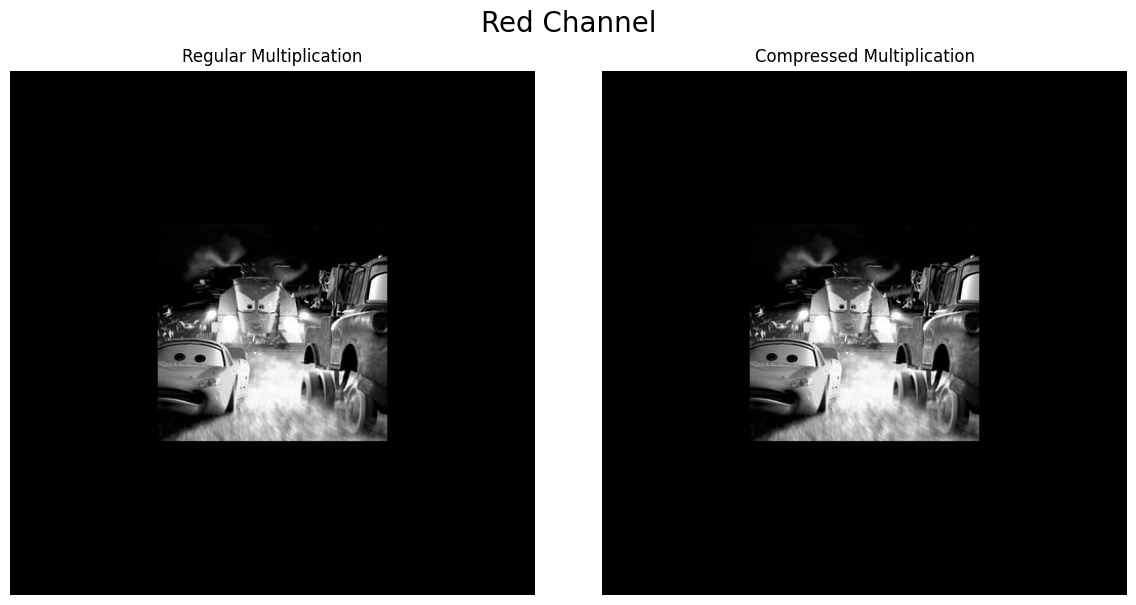

Number of matching values: 258179/262144
Percentage of matching values: 98.49%


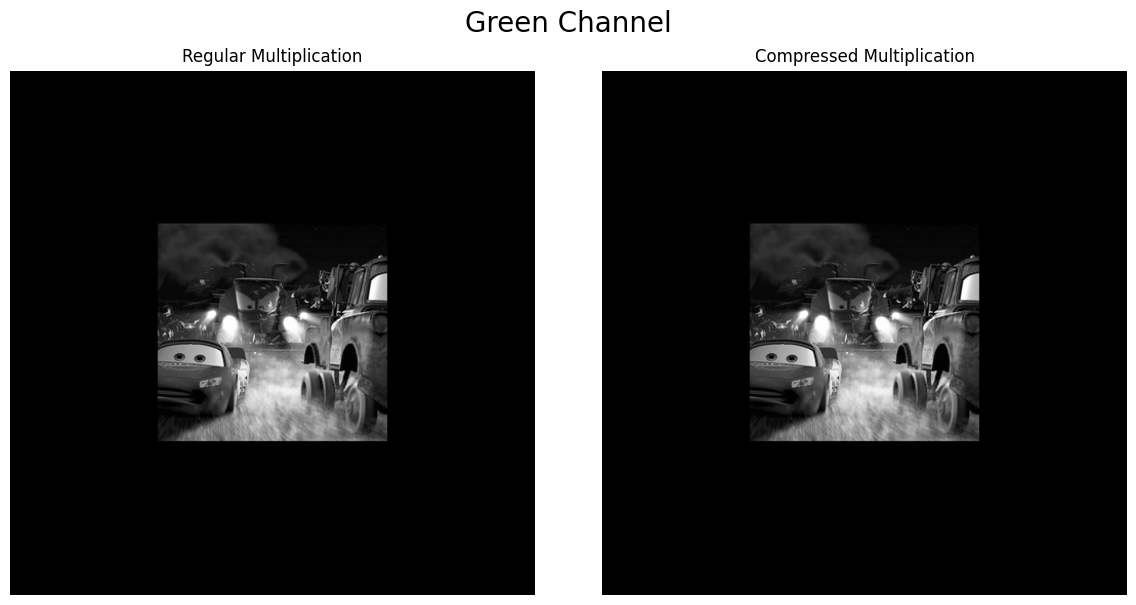

Number of matching values: 259383/262144
Percentage of matching values: 98.95%


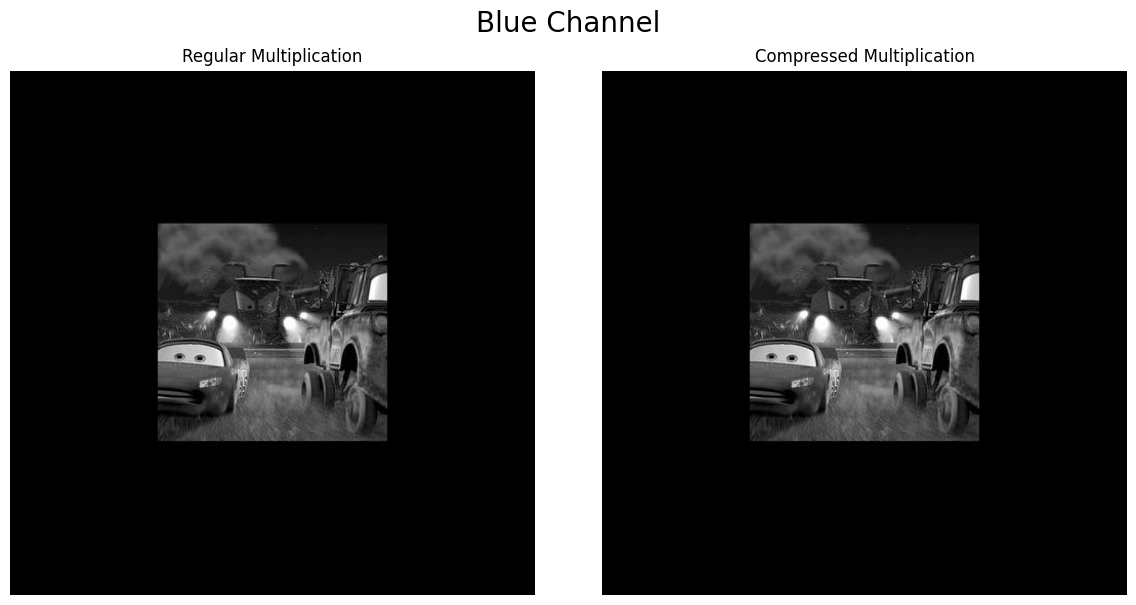

Number of matching values: 260591/262144
Percentage of matching values: 99.41%


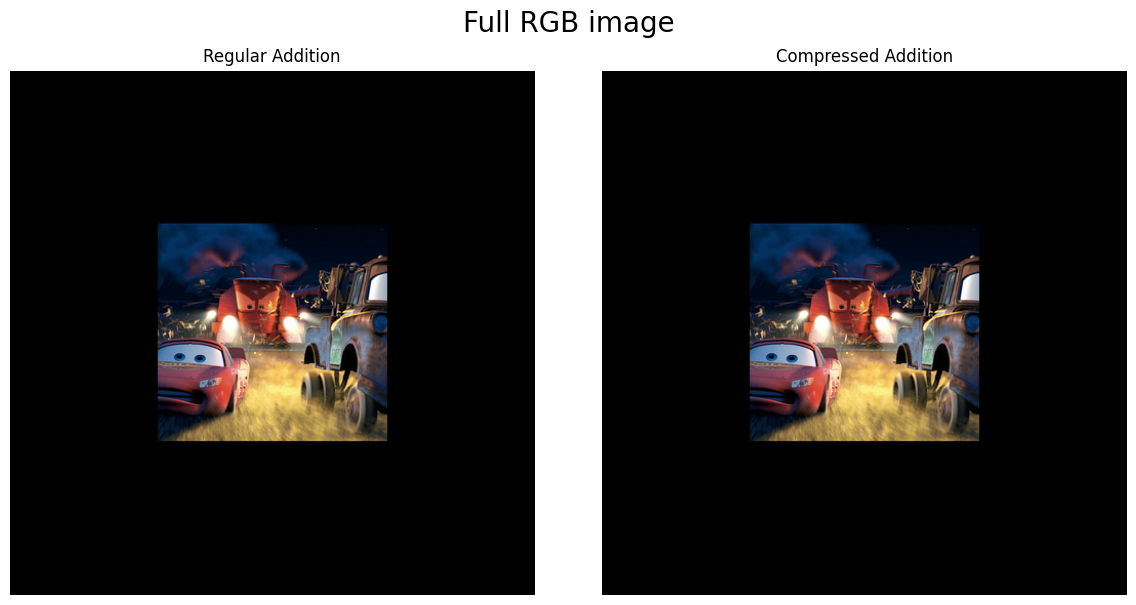

Number of matching values: 778153/786432
Percentage of matching values: 98.95%


In [565]:
compare_image_multiplications(image, max_block_size = 4, target_svd_components = 256, lambda_reg=1e-8, threshold_reg=1e-8)

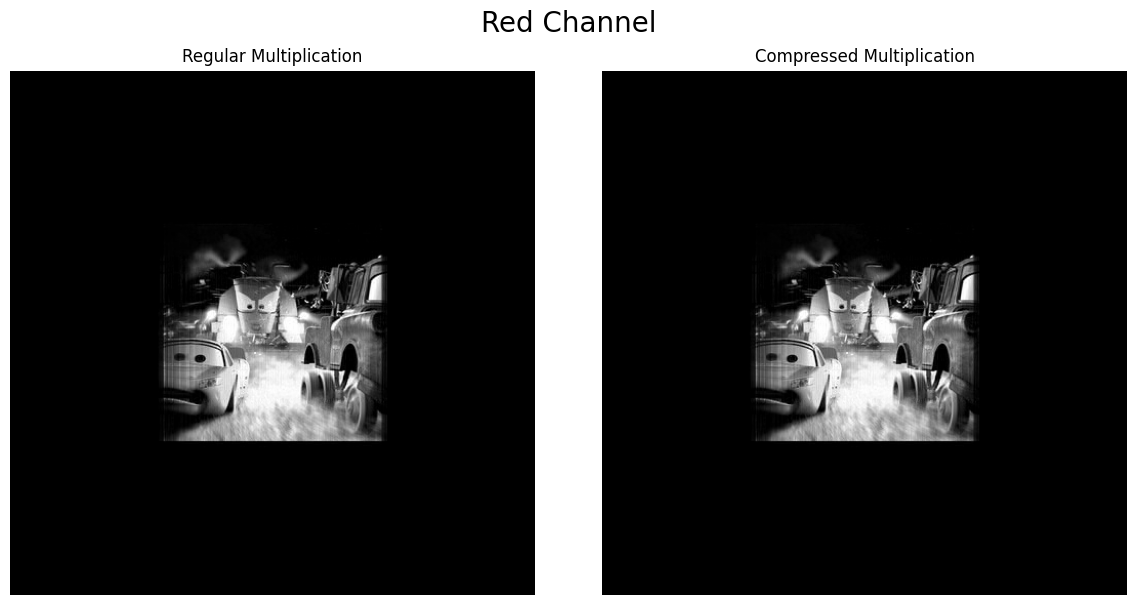

Number of matching values: 262132/262144
Percentage of matching values: 100.00%


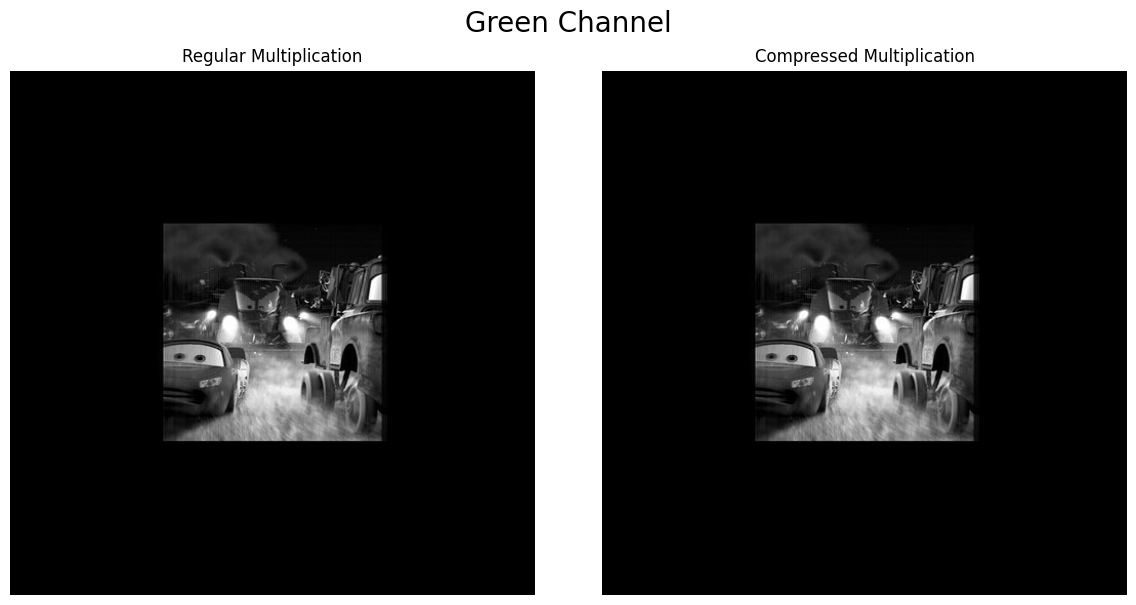

Number of matching values: 262144/262144
Percentage of matching values: 100.00%


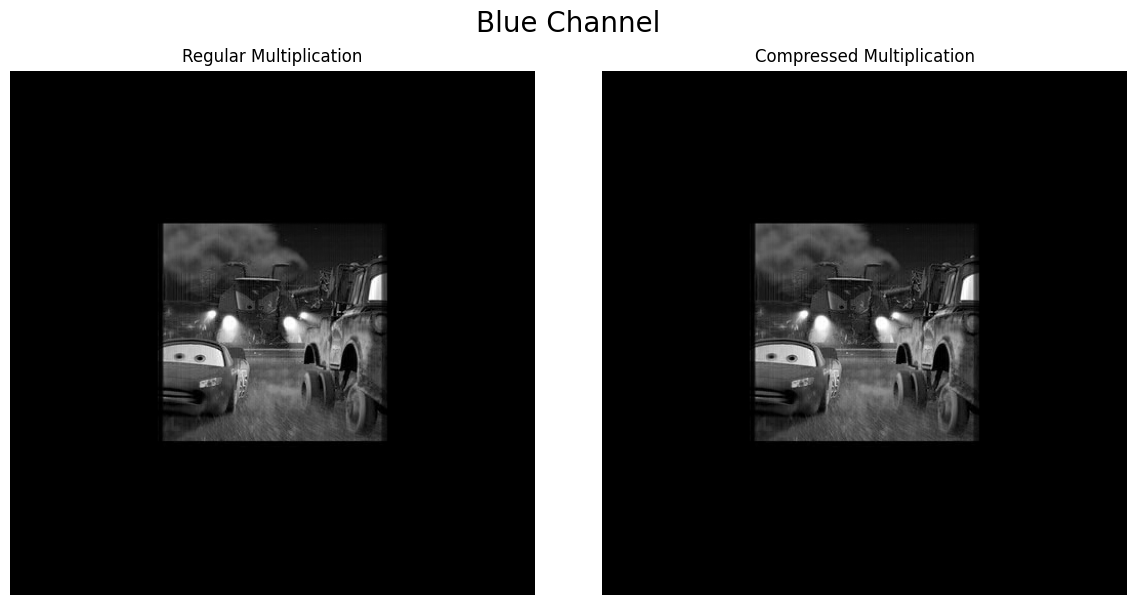

Number of matching values: 262144/262144
Percentage of matching values: 100.00%


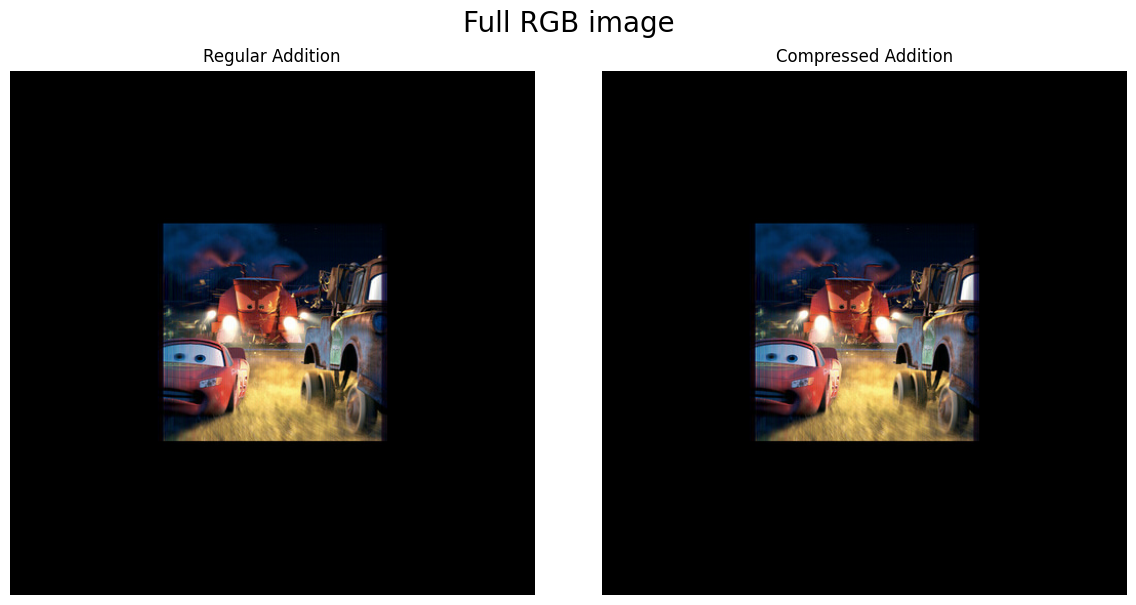

Number of matching values: 786420/786432
Percentage of matching values: 100.00%


In [510]:
compare_image_multiplications(image, max_block_size = 4, target_svd_components = 256, lambda_reg=0.01, threshold_reg=0.01)

## Wykresy

#### Wykres zalezności rozmiaru macierzy od czasu trawania algorytmu mnożenia macierzy przez wektor na przykładzie macierzy odwzorowujących topologię siatki 3D.

In [54]:
def measure_compressed_matrix_vector_multiplication_time(matrix_generator, k_values):
    sizes = []
    times = []

    for k in k_values:
        size = 2**(3 * k)
        sizes.append(size)
        compressed_matrix_tree = matrix_generator(k)
        vector = np.random.rand(size)

        elapsed_time = 0
        nr_iterations = 1
        while elapsed_time == 0:
            start_time = time.time()
            for _ in range(nr_iterations):
                _ = compressed_matrix_vector_mult(compressed_matrix_tree, vector)
            elapsed_time = time.time() - start_time
            nr_iterations *= 10
        nr_iterations /= 10
        
        times.append(elapsed_time / nr_iterations)
    return sizes, times

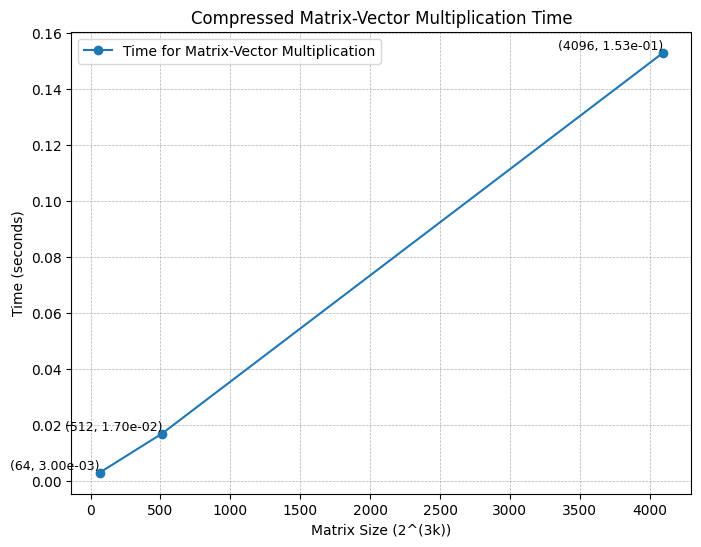

In [55]:
k_values = [2,3,4]
sizes, times = measure_compressed_matrix_vector_multiplication_time(generate_compressed_mesh_matrix_tree, k_values)

plt.figure(figsize=(8, 6))
plt.plot(sizes, times, marker='o', linestyle='-', label="Time for Matrix-Vector Multiplication")
for x, y in zip(sizes, times):
    plt.text(x, y, f"({x}, {y:.2e})", fontsize=9, ha='right', va='bottom')
plt.xlabel("Matrix Size (2^(3k))")
plt.ylabel("Time (seconds)")
plt.title("Compressed Matrix-Vector Multiplication Time")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

#### Dopasowanie krzywej o wzorze $a \cdot N^b$ do poprzedniego wykresu i wyznaczenie jej parametrów

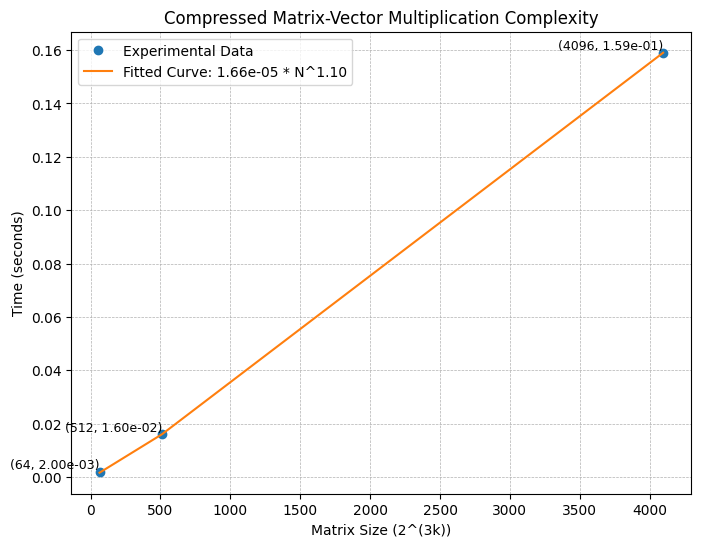

a = 1.6617608963889288e-05
b = 1.102008285124533


In [561]:
def complexity_model(N, a, b):
    return a * N**b

k_values = [2, 3, 4]
sizes, times = measure_compressed_matrix_vector_multiplication_time(generate_compressed_mesh_matrix_tree, k_values)

popt, _ = curve_fit(complexity_model, sizes, times) # curve_fit from scipy.optimize
a, b = popt
fitted_times = complexity_model(np.array(sizes), a, b)

plt.figure(figsize=(8, 6))
plt.plot(sizes, times, 'o', label="Experimental Data")
plt.plot(sizes, fitted_times, '-', label=f"Fitted Curve: {a:.2e} * N^{b:.2f}")
for x, y in zip(sizes, times):
    plt.text(x, y, f"({x}, {y:.2e})", fontsize=9, ha='right', va='bottom')
plt.xlabel("Matrix Size (2^(3k))")
plt.ylabel("Time (seconds)")
plt.title("Compressed Matrix-Vector Multiplication Complexity")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

print(f'a = {a}')
print(f'b = {b}')

#### Wyznaczenie Normy Frobeniusa w zależności od rozmiaru macierzy dla dekonstrukcji macierzy gęstej z macierzy skompresowanej

In [517]:
def frobenius_norm_difference(matrix_dense, matrix_compressed_squared):
    difference = matrix_dense - matrix_compressed_squared
    frobenius_norm = np.linalg.norm(difference, ord='fro')
    return frobenius_norm

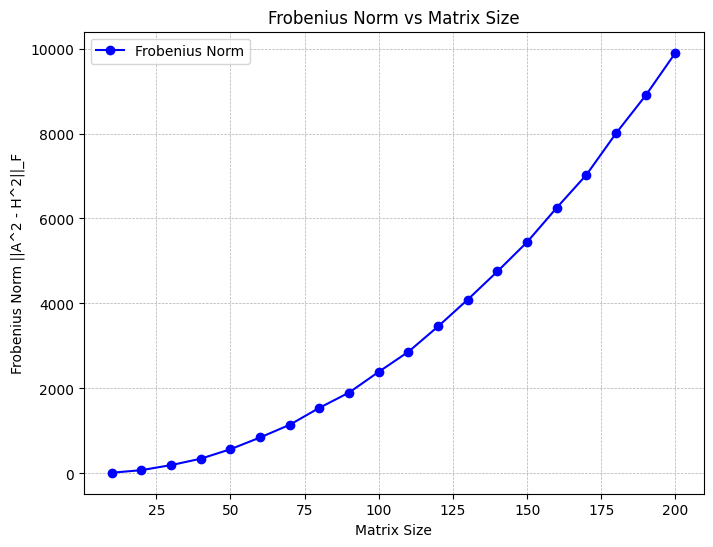

In [518]:
sizes = [i for i in range(10, 201, 10)]
frobenius_norms = []

for size in sizes:
    matrix_dense = np.random.rand(size, size).astype(np.float32)
    compressed_matrix_tree = create_tree(matrix_dense, max_block_size=2, sv_threshold=0.1)
    matrix_dense_squared = matrix_dense @ matrix_dense
    compressed_matrix_squared = compressed_matrix_mult(compressed_matrix_tree, compressed_matrix_tree).matrix
    frobenius_norm = frobenius_norm_difference(matrix_dense_squared, compressed_matrix_squared)
    frobenius_norms.append(frobenius_norm)

plt.figure(figsize=(8, 6))
plt.plot(sizes, frobenius_norms, marker='o', linestyle='-', color='b', label="Frobenius Norm")
plt.xlabel("Matrix Size")
plt.ylabel("Frobenius Norm ||A^2 - H^2||_F")
plt.title("Frobenius Norm vs Matrix Size")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()